Wrote: D:\Phd Research\Flood_Plain_Alteration\Tiff\lulc_change_count_2001_2005.tif
Wrote: D:\Phd Research\Flood_Plain_Alteration\Tiff\lulc_change_intensity_2001_2005.tif


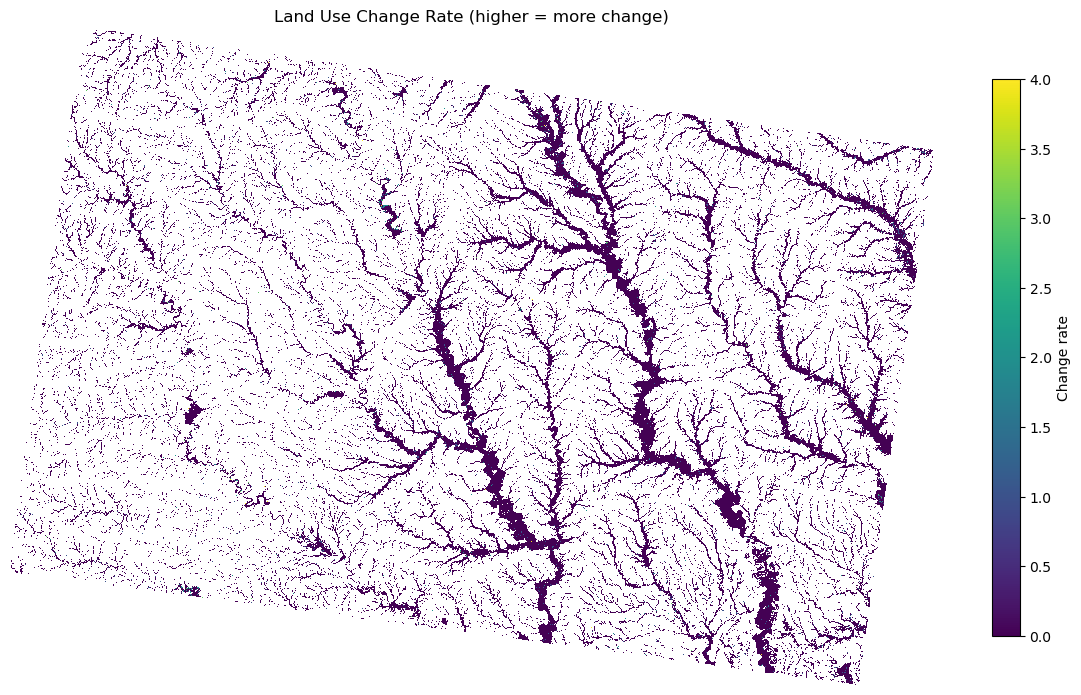

Wrote: D:\Phd Research\Flood_Plain_Alteration\Tiff\lulc_change_rate_2001_2005.jpg


In [1]:
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

# ----------------------------
# Inputs (UPDATED PATHS)
# ----------------------------
tifs = [
    r"D:\Phd Research\Flood_Plain_Alteration\Tiff\2001.tif",
    r"D:\Phd Research\Flood_Plain_Alteration\Tiff\2002.tif",
    r"D:\Phd Research\Flood_Plain_Alteration\Tiff\2003.tif",
    r"D:\Phd Research\Flood_Plain_Alteration\Tiff\2004.tif",
    r"D:\Phd Research\Flood_Plain_Alteration\Tiff\2005.tif",
]

# Output files (UPDATED PATHS)
out_change_count_tif = r"D:\Phd Research\Flood_Plain_Alteration\Tiff\lulc_change_count_2001_2005.tif"
out_change_intensity_tif = r"D:\Phd Research\Flood_Plain_Alteration\Tiff\lulc_change_intensity_2001_2005.tif"
out_jpg = r"D:\Phd Research\Flood_Plain_Alteration\Tiff\lulc_change_rate_2001_2005.jpg"

# ----------------------------
# Open rasters and validate grid
# ----------------------------
srcs = [rasterio.open(fp) for fp in tifs]
ref = srcs[0]
H, W = ref.height, ref.width
nodata = ref.nodata
meta = ref.meta.copy()

for s in srcs[1:]:
    if (s.height, s.width) != (H, W):
        raise ValueError("Grid mismatch: rasters have different shape.")
    if s.transform != ref.transform:
        raise ValueError("Grid mismatch: rasters have different transform.")
    if s.crs != ref.crs:
        raise ValueError("Grid mismatch: rasters have different CRS.")

os.makedirs(os.path.dirname(out_change_count_tif), exist_ok=True)

# ----------------------------
# Output metadata
# ----------------------------
meta_count = meta.copy()
meta_count.update(count=1, dtype="uint8", nodata=255, compress="lzw", tiled=True)

meta_intensity = meta.copy()
meta_intensity.update(count=1, dtype="float32", nodata=np.nan, compress="lzw", tiled=True)

# ----------------------------
# Compute change-rate maps block-wise
# ----------------------------
with rasterio.open(out_change_count_tif, "w", **meta_count) as dst_count, \
     rasterio.open(out_change_intensity_tif, "w", **meta_intensity) as dst_int:

    for _, window in ref.block_windows(1):
        # Read 5-year stack for this block
        stack = np.stack([s.read(1, window=window) for s in srcs], axis=0)

        # Valid mask (exclude nodata across time)
        valid = np.ones(stack.shape[1:], dtype=bool)
        if nodata is not None:
            valid &= ~np.any(stack == nodata, axis=0)
        valid &= np.all(np.isfinite(stack.astype("float32")), axis=0)

        # --- 1) CHANGE COUNT (best for categorical LULC) ---
        diffs = stack[1:, :, :] != stack[:-1, :, :]
        change_count = np.sum(diffs, axis=0).astype(np.uint8)  # range: 0..4
        change_count_out = np.where(valid, change_count, 255).astype(np.uint8)

        # --- 2) CHANGE INTENSITY (best for continuous rasters) ---
        stack_f = stack.astype(np.float32)
        absdiff = np.abs(stack_f[1:, :, :] - stack_f[:-1, :, :])
        change_intensity = np.sum(absdiff, axis=0).astype(np.float32)
        change_intensity_out = np.where(valid, change_intensity, np.nan).astype(np.float32)

        # Write blocks
        dst_count.write(change_count_out, 1, window=window)
        dst_int.write(change_intensity_out, 1, window=window)

print("Wrote:", out_change_count_tif)
print("Wrote:", out_change_intensity_tif)

# close sources
for s in srcs:
    s.close()

# ----------------------------
# Preview map + export JPG
# ----------------------------
preview_mode = "count"  # change to "intensity" if your data are continuous
preview_tif = out_change_count_tif if preview_mode == "count" else out_change_intensity_tif

with rasterio.open(preview_tif) as src:
    target_width = 2500
    scale = max(1, int(np.ceil(src.width / target_width)))
    out_h = max(1, src.height // scale)
    out_w = max(1, src.width // scale)

    preview = src.read(
        1,
        out_shape=(out_h, out_w),
        resampling=Resampling.nearest if preview_mode == "count" else Resampling.average
    )

# Mask nodata in preview for cleaner plotting
if preview_mode == "count":
    preview = np.where(preview == 255, np.nan, preview)

plt.figure(figsize=(12, 7))
im = plt.imshow(preview, interpolation="nearest")
plt.title("Land Use Change Rate (higher = more change)")
plt.axis("off")
cbar = plt.colorbar(im, shrink=0.85)
cbar.set_label("Change rate")

plt.tight_layout()
plt.savefig(out_jpg, dpi=200)
plt.show()

print("Wrote:", out_jpg)